---
# COSC2753 | Machine Learning

## Task 1 — Member 1: Article-Type Classification
---

# 1. Introduction

This notebook is the complete Task 1 workflow: target-specific EDA, a majority baseline, an independently initialized CNN, validation-based selection, test evaluation, checkpoint saving, and inference. Article type is a severe long-tail problem, so macro F1 is primary and top-3 accuracy is supporting evidence.

# 2. Library Imports and Setup

In [1]:
from copy import deepcopy
from pathlib import Path
import json, sys, time

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, top_k_accuracy_score)
from skimage.feature import hog
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from preprocessing import IMAGE_SIZE, NORMALISATION_PATH, SEED, seed_everything, select_torch_device, task_frame

seed_everything(SEED)
torch.manual_seed(SEED)
DEVICE = select_torch_device()
DEVICE

Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


device(type='cuda')

# 3. Load the Frozen Data

In [2]:
TARGET = 'articleType'
train_df = task_frame(TARGET, 'train')
validation_df = task_frame(TARGET, 'validation')
test_df = task_frame(TARGET, 'test')
with NORMALISATION_PATH.open(encoding='utf-8') as handle:
    normalisation = json.load(handle)
labels = sorted(train_df[TARGET].unique())
label_to_index = {label: index for index, label in enumerate(labels)}
len(train_df), len(validation_df), len(test_df), len(labels)

(27051, 5842, 5718, 124)

# 4. Target-Specific EDA

count     124.000000
mean      218.153226
std       553.542575
min         1.000000
25%         6.000000
50%        30.500000
75%       168.250000
max      4759.000000
Name: count, dtype: float64

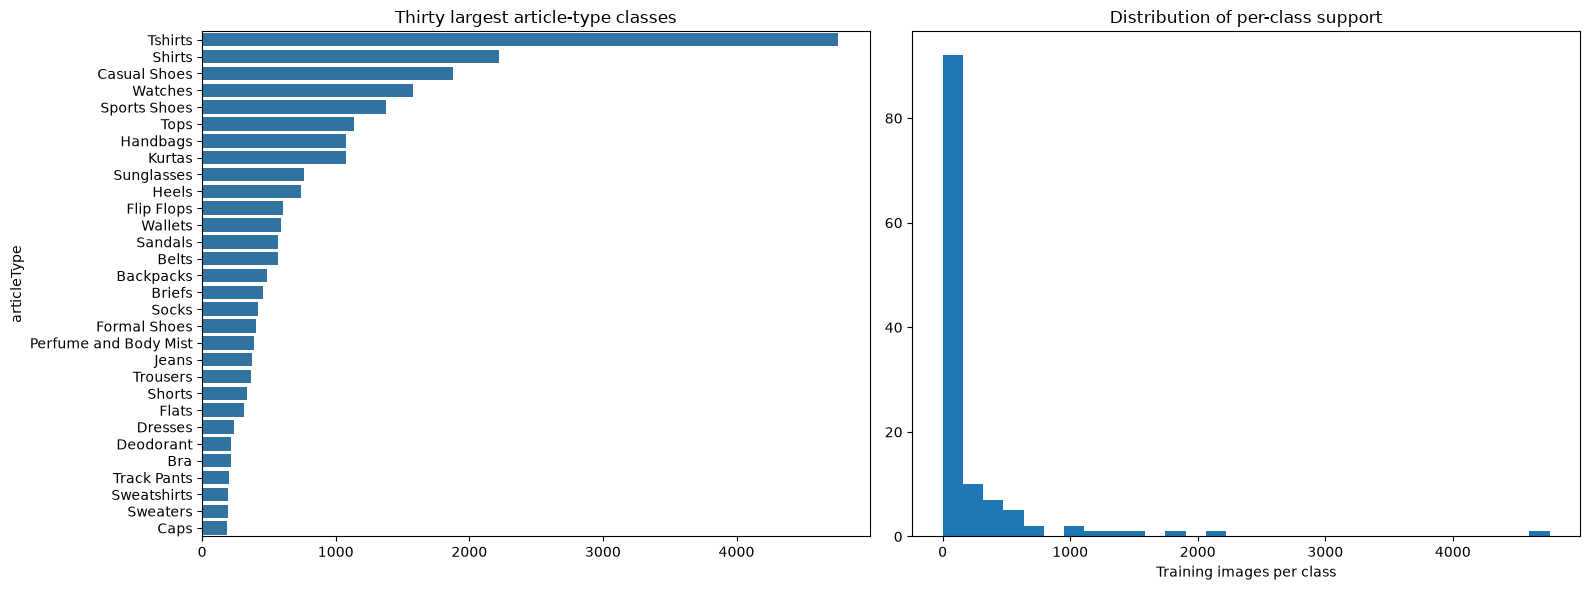

In [3]:
counts = train_df[TARGET].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=counts.head(30).values, y=counts.head(30).index, ax=axes[0])
axes[0].set_title('Thirty largest article-type classes')
axes[1].hist(counts.values, bins=30)
axes[1].set_title('Distribution of per-class support')
axes[1].set_xlabel('Training images per class')
plt.tight_layout()
counts.describe()

## 4.1 Observations

Define head, medium, and tail support thresholds here. Check whether every validation/test label exists in training and discuss unsupported or extremely rare classes. Inspect visually adjacent labels before choosing loss weighting.

In [4]:
{
    'validation_only': sorted(set(validation_df[TARGET]) - set(labels)),
    'test_only': sorted(set(test_df[TARGET]) - set(labels)),
    'classes_below_10': int((counts < 10).sum()),
    'classes_below_50': int((counts < 50).sum()),
}

{'validation_only': [],
 'test_only': [],
 'classes_below_10': 42,
 'classes_below_50': 72}

# 5. Majority Baseline

In [5]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(np.zeros((len(train_df), 1)), train_df[TARGET])
dummy_predictions = dummy.predict(np.zeros((len(validation_df), 1)))
{
    'accuracy': accuracy_score(validation_df[TARGET], dummy_predictions),
    'macro_f1': f1_score(validation_df[TARGET], dummy_predictions, average='macro', zero_division=0),
}

{'accuracy': 0.17750770284149264, 'macro_f1': 0.0028990126024578703}

# 6. HOG + HSV Classical Baseline

HOG represents garment shape while HSV histograms represent colour. The class-weighted linear model tests how far transparent handcrafted features can go before deep learning.

In [6]:
def handcrafted_feature(path):
    with Image.open(path) as source:
        image = source.convert('RGB').resize((48, 64))
    array = np.asarray(image, dtype=np.float32) / 255.0
    gray = array.mean(axis=2)
    shape = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
    hsv = np.asarray(image.convert('HSV'), dtype=np.float32) / 255.0
    colour = np.concatenate([np.histogram(hsv[..., channel], bins=8, range=(0, 1), density=True)[0] for channel in range(3)])
    return np.concatenate([shape, colour]).astype(np.float32)

def feature_matrix(frame):
    return np.vstack([handcrafted_feature(path) for path in frame.image_path])

train_features = feature_matrix(train_df)
validation_features = feature_matrix(validation_df)
linear_baseline = LogisticRegression(class_weight='balanced', max_iter=300, n_jobs=-1)
linear_baseline.fit(train_features, train_df[TARGET])
linear_predictions = linear_baseline.predict(validation_features)
{
    'accuracy': accuracy_score(validation_df[TARGET], linear_predictions),
    'macro_f1': f1_score(validation_df[TARGET], linear_predictions, average='macro', zero_division=0),
}

D:\khoile\programs\fashion-intelligence-classification\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


D:\khoile\programs\fashion-intelligence-classification\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'accuracy': 0.7742211571379665, 'macro_f1': 0.5879645071632214}

# 7. Image Pipeline

Augmentation is applied only to training images. Validation and test images use deterministic RGB conversion, resize, tensor conversion, and training-fitted normalisation.

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=8, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.12, contrast=0.12),
    transforms.ToTensor(),
    transforms.Normalize(normalisation['mean'], normalisation['std']),
])
evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])),
    transforms.ToTensor(),
    transforms.Normalize(normalisation['mean'], normalisation['std']),
])

class FashionDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.image_path) as image:
            tensor = self.transform(image.convert('RGB'))
        return tensor, label_to_index[row[TARGET]]

train_loader = DataLoader(FashionDataset(train_df, train_transform), batch_size=64, shuffle=True, num_workers=0)
validation_loader = DataLoader(FashionDataset(validation_df, evaluation_transform), batch_size=128, num_workers=0)
test_loader = DataLoader(FashionDataset(test_df, evaluation_transform), batch_size=128, num_workers=0)

# 8. Compact Residual CNN From Scratch

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, input_channels, output_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, output_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(output_channels)
        self.conv2 = nn.Conv2d(output_channels, output_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Identity() if input_channels == output_channels and stride == 1 else nn.Sequential(
            nn.Conv2d(input_channels, output_channels, 1, stride, bias=False), nn.BatchNorm2d(output_channels),
        )
    def forward(self, inputs):
        residual = self.shortcut(inputs)
        outputs = self.relu(self.bn1(self.conv1(inputs)))
        outputs = self.bn2(self.conv2(outputs))
        return self.relu(outputs + residual)

class CompactCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.2):
        super().__init__()
        self.features = nn.Sequential(
            ResidualBlock(3, 32), nn.MaxPool2d(2),
            ResidualBlock(32, 64), nn.MaxPool2d(2),
            ResidualBlock(64, 128), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(128, num_classes))
    def forward(self, inputs):
        return self.classifier(self.features(inputs))

model = CompactCNN(len(labels)).to(DEVICE)
sum(parameter.numel() for parameter in model.parameters())

314236

# 9. Class-Balanced Training

In [9]:
# Run once with 'ordinary' and once with 'class_balanced', resetting the model and seed each time.
LOSS_MODE = 'class_balanced'
class_counts = train_df[TARGET].value_counts().reindex(labels).values
beta = 0.9999
effective_number = 1.0 - np.power(beta, class_counts)
class_weights = (1.0 - beta) / effective_number
class_weights = class_weights / class_weights.mean()
loss_weights = None if LOSS_MODE == 'ordinary' else torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=loss_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    losses, true_labels, predicted_labels = [], [], []
    for images, targets in loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, targets)
            if training:
                loss.backward()
                optimizer.step()
        losses.append(loss.item() * len(targets))
        true_labels.extend(targets.cpu().tolist())
        predicted_labels.extend(logits.argmax(1).cpu().tolist())
    return {
        'loss': sum(losses) / len(loader.dataset),
        'accuracy': accuracy_score(true_labels, predicted_labels),
        'macro_f1': f1_score(true_labels, predicted_labels, average='macro', zero_division=0),
    }

In [10]:
history, best_state, best_f1, patience = [], None, -1.0, 0
for epoch in range(1, 41):
    started = time.perf_counter()
    train_metrics = run_epoch(model, train_loader, optimizer)
    validation_metrics = run_epoch(model, validation_loader)
    history.append({'epoch': epoch, 'loss_mode': LOSS_MODE, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'validation_{k}': v for k, v in validation_metrics.items()}})
    print(epoch, validation_metrics, f'{time.perf_counter() - started:.1f}s')
    if validation_metrics['macro_f1'] > best_f1:
        best_f1, best_state, patience = validation_metrics['macro_f1'], deepcopy(model.state_dict()), 0
    else:
        patience += 1
        if patience >= 7:
            break
model.load_state_dict(best_state)
history = pd.DataFrame(history)

1 {'loss': 4.433074913625642, 'accuracy': 0.14429989729544676, 'macro_f1': 0.022413169193045732} 80.7s


2 {'loss': 4.361772231637758, 'accuracy': 0.11211913728175282, 'macro_f1': 0.01800627937971017} 59.0s


3 {'loss': 3.9219365327254585, 'accuracy': 0.21157137966449846, 'macro_f1': 0.0695697833022927} 57.3s


4 {'loss': 3.7513170317402036, 'accuracy': 0.19120164327285177, 'macro_f1': 0.06727332284853026} 58.6s


5 {'loss': 3.5265658563720326, 'accuracy': 0.21961656966792195, 'macro_f1': 0.10706855385994632} 57.2s


...

36 {'loss': 2.0782262625166994, 'accuracy': 0.5718931872646354, 'macro_f1': 0.3453867712295094} 56.3s


37 {'loss': 2.1110313589219483, 'accuracy': 0.5386853817185895, 'macro_f1': 0.32224337357495675} 57.4s


38 {'loss': 2.0480117752143103, 'accuracy': 0.5638479972612119, 'macro_f1': 0.3478871246127584} 57.7s


39 {'loss': 2.046589355442631, 'accuracy': 0.5999657651489216, 'macro_f1': 0.3776355287626695} 57.6s


40 {'loss': 2.964298731494709, 'accuracy': 0.5256761383087983, 'macro_f1': 0.29645015937540425} 56.8s


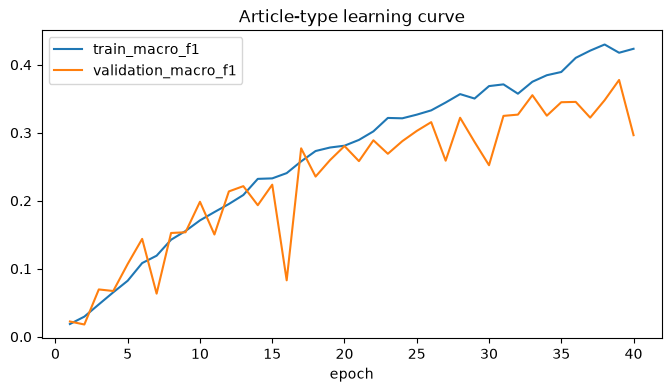

In [11]:
history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'], figsize=(8, 4), title='Article-type learning curve')
plt.show()

## 8.1 Training analysis

Interpret convergence, the train-validation gap, and the epoch selected by validation macro F1. Compare ordinary and weighted loss as controlled runs before finalizing this cell's configuration.

# 10. Final Evaluation and Failure Analysis

Run this section only after model choices are frozen.

In [12]:
@torch.inference_mode()
def predict_loader(model, loader):
    model.eval()
    probabilities, truth = [], []
    for images, targets in loader:
        probabilities.append(model(images.to(DEVICE)).softmax(1).cpu().numpy())
        truth.extend(targets.tolist())
    return np.vstack(probabilities), np.asarray(truth)

test_probabilities, test_truth = predict_loader(model, test_loader)
test_predictions = test_probabilities.argmax(1)
test_metrics = {
    'accuracy': accuracy_score(test_truth, test_predictions),
    'macro_f1': f1_score(test_truth, test_predictions, average='macro', zero_division=0),
    'top_3_accuracy': top_k_accuracy_score(test_truth, test_probabilities, k=3, labels=np.arange(len(labels))),
}
test_metrics

{'accuracy': 0.6073802028681358,
 'macro_f1': 0.3674285409717533,
 'top_3_accuracy': 0.8336831059811123}

In [13]:
print(classification_report(
    test_truth, test_predictions, labels=np.arange(len(labels)), target_names=labels, zero_division=0,
))

                       precision    recall  f1-score   support

   Accessory Gift Set       0.95      1.00      0.97        18
           Baby Dolls       0.00      0.00      0.00         0
            Backpacks       0.79      0.75      0.77       110
               Bangle       0.00      0.00      0.00         2
          Basketballs       0.00      0.00      0.00         1
                Belts       0.98      0.90      0.94       132
              Blazers       0.00      0.00      0.00         3
  Body Wash and Scrub       0.00      0.00      0.00         0
              Booties       0.40      1.00      0.57         2
               Boxers       0.40      0.40      0.40         5
                  Bra       0.84      0.84      0.84        31
             Bracelet       0.00      0.00      0.00         1
               Briefs       0.95      0.90      0.92       106
            Camisoles       0.00      0.00      0.00         1
               Capris       0.54      0.58      0.56  

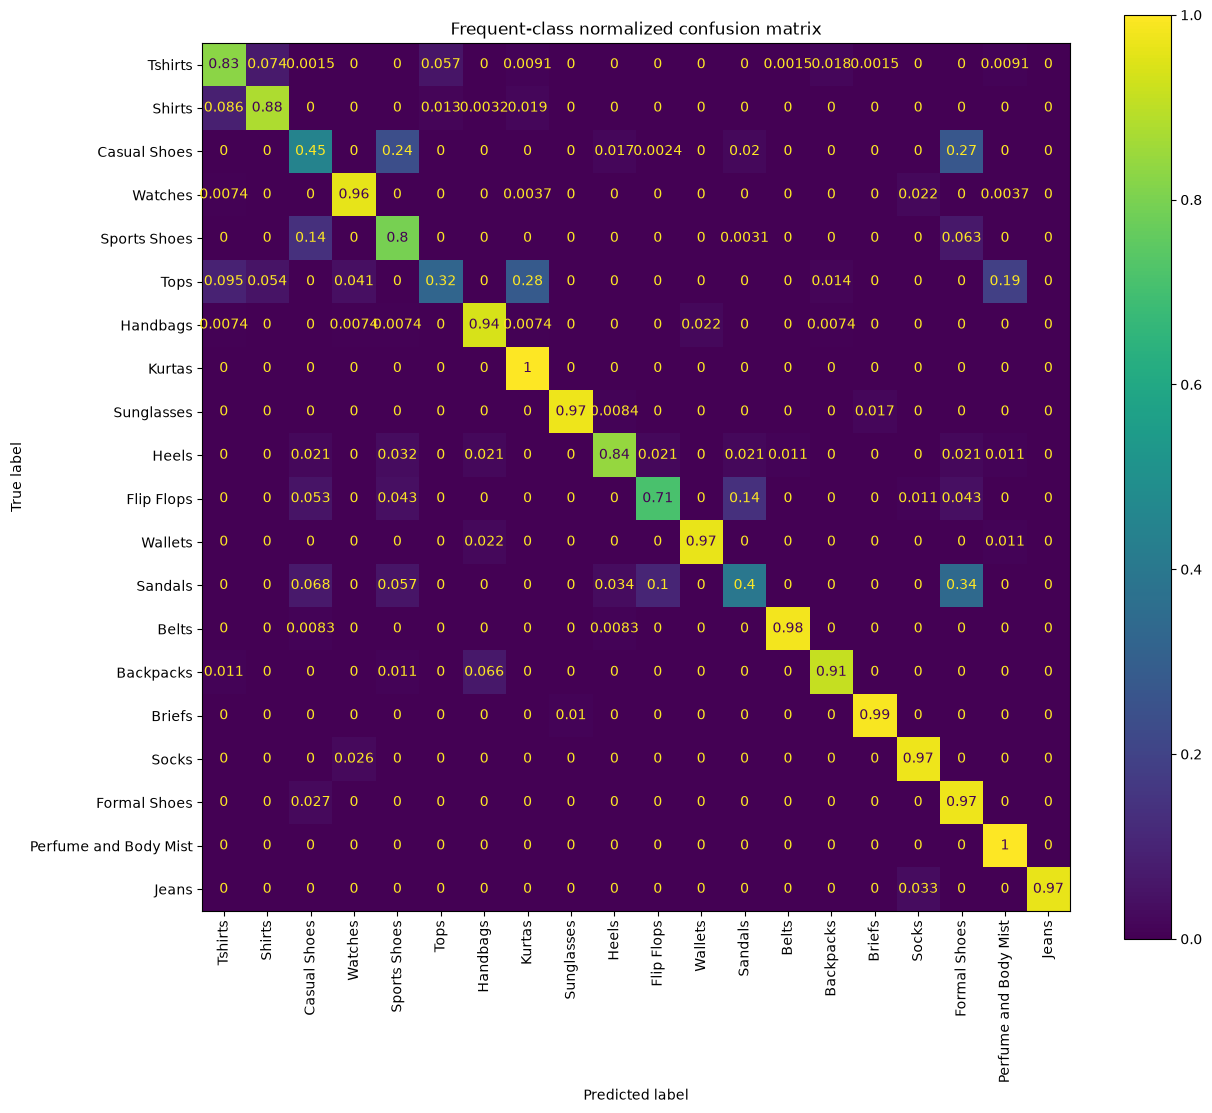

In [14]:
largest_labels = counts.head(20).index
largest_indices = [label_to_index[label] for label in largest_labels]
selected = np.isin(test_truth, largest_indices)
fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    test_truth[selected], test_predictions[selected], labels=largest_indices,
    display_labels=largest_labels, normalize='true', xticks_rotation=90, ax=ax,
)
plt.title('Frequent-class normalized confusion matrix')
plt.show()

## 9.1 Failure analysis

Report head/medium/tail macro F1, the most frequent confusion pairs, high-confidence mistakes, robustness to mild brightness/blur changes, inference latency, and checkpoint size. Do not claim reliable performance for labels with inadequate test support.

# 11. Save the Selected Model

In [15]:
checkpoint_path = ROOT / 'models' / 'article_type_model.pt'
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    'target': TARGET, 'labels': labels, 'state_dict': model.cpu().state_dict(),
    'mean': normalisation['mean'], 'std': normalisation['std'],
    'image_size': list(IMAGE_SIZE), 'dropout': 0.2, 'selection_metric': 'validation_macro_f1',
    'best_validation_macro_f1': best_f1, 'test_metrics': test_metrics, 'seed': SEED,
}, checkpoint_path)
history.to_csv(ROOT / 'models' / 'article_type_history.csv', index=False)
checkpoint_path

WindowsPath('D:/khoile/programs/fashion-intelligence-classification/models/article_type_model.pt')

# 12. Final Prediction Check

In [16]:
# Run from the repository root after saving:
# python scripts/task1_article_type_classification.py path/to/image.jpg

# 13. Ultimate Judgement and Conclusion

Replace this prompt with the measured comparison among majority, HOG+HSV, ordinary-loss residual CNN, and class-balanced residual CNN; include the selected epoch, macro/top-3 results, major confusions, efficiency, limitations, and why this checkpoint is suitable for integration.